# Wolf Sheep Simple 3 — Ecossistema Evolutivo com Mesa e Mendel

Este notebook transforma o modelo **Wolf Sheep Simple 3** em um **ecossistema evolutivo baseado em agentes**.

Foram adicionados:

- Genótipos e alelos.
- Herança genética mendeliana.
- Recombinação durante a reprodução.
- Mutação.
- Fenótipos derivados dos genes.
- Seleção natural.
- Frequências alélicas ao longo do tempo.
- Comparação com Lotka-Volterra.
- Exportação para CSV.

A simulação usa a biblioteca **Mesa**.

## 1. Relação com Mendel e Evolução

### Primeira Lei de Mendel
Cada indivíduo possui dois alelos para cada gene, mas transmite apenas um alelo ao descendente.

### Segunda Lei de Mendel
Genes diferentes são herdados independentemente. Neste modelo, visão, fuga/caça, resistência e fertilidade são recombinadas independentemente.

### Seleção Natural
Depois da herança, o ambiente seleciona os indivíduos que sobrevivem mais e deixam mais descendentes.

In [35]:
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

df_genotipos

try:
    import mesa
    from mesa import Agent, Model
    from mesa.datacollection import DataCollector
    from mesa.space import MultiGrid
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "Mesa não está instalado. Use: /opt/conda/bin/python -m pip install --user mesa"
    ) from e

print("Mesa importado com sucesso")
try:
    print("Versão Mesa:", mesa.__version__)
except Exception:
    pass

Mesa importado com sucesso
Versão Mesa: 3.3.1


In [12]:
params = {
    "width": 50,
    "height": 50,
    "grass_max": 10.0,
    "grass_regrowth": 0.45,
    "obstacle_density": 0.05,
    "initial_sheep": 160,
    "initial_wolves": 45,
    "initial_sheep_energy": 24.0,
    "initial_wolf_energy": 36.0,
    "sheep_movement_cost": 1.0,
    "wolf_movement_cost": 1.2,
    "energy_gain_from_grass": 4.0,
    "energy_gain_from_sheep": 22.0,
    "sheep_reproduction_threshold": 34.0,
    "wolf_reproduction_threshold": 48.0,
    "base_sheep_reproduction_prob": 0.045,
    "base_wolf_reproduction_prob": 0.025,
    "offspring_energy_fraction": 0.45,
    "max_hunger_sheep": 18,
    "max_hunger_wolf": 24,
    "max_age_sheep": 90,
    "max_age_wolf": 120,
    "mutation_rate": 0.01,
    "initial_disease_prob": 0.02,
    "disease_spread_prob": 0.06,
    "disease_energy_cost": 1.2,
    "disease_death_prob": 0.01,
    "disease_recovery_prob": 0.015,
    "n_steps": 300,
    "random_seed": 42,
}
print('Parâmetros Definidos.')

Parâmetros Definidos.


## 2. Genes do modelo

### Ovelhas

- `V`: visão.
- `S`: velocidade/fuga.
- `R`: resistência à doença.
- `F`: fertilidade.

### Lobos

- `V`: visão.
- `H`: habilidade de caça.
- `R`: resistência à doença.
- `F`: fertilidade.

Cada gene tem dois alelos: dominante maiúsculo e recessivo minúsculo.

In [8]:
SHEEP_GENES = ["V", "S", "R", "F"]
WOLF_GENES = ["V", "H", "R", "F"]

ALLELES = {
    "V": ("V", "v"),
    "S": ("S", "s"),
    "H": ("H", "h"),
    "R": ("R", "r"),
    "F": ("F", "f"),
}


def make_random_genome(genes, dominant_prob=0.5):
    genome = {}
    for gene in genes:
        dom, rec = ALLELES[gene]
        a1 = dom if random.random() < dominant_prob else rec
        a2 = dom if random.random() < dominant_prob else rec
        genome[gene] = (a1, a2)
    return genome


def mutate_allele(gene, allele):
    dom, rec = ALLELES[gene]
    return rec if allele == dom else dom


def inherit_genome(parent_a, parent_b, mutation_rate=0.01):
    child = {}
    for gene in parent_a:
        a1 = random.choice(parent_a[gene])
        a2 = random.choice(parent_b[gene])
        if random.random() < mutation_rate:
            a1 = mutate_allele(gene, a1)
        if random.random() < mutation_rate:
            a2 = mutate_allele(gene, a2)
        child[gene] = (a1, a2)
    return child


def dominant_count(genome, gene):
    dom = ALLELES[gene][0]
    return sum(1 for a in genome[gene] if a == dom)


def genotype_str(genome):
    return " ".join(f"{g}:{''.join(genome[g])}" for g in sorted(genome))


def allele_frequency(agents, gene):
    if not agents:
        return 0.0
    dom = ALLELES[gene][0]
    total = 0
    count = 0
    for a in agents:
        if gene in a.genome:
            total += 2
            count += sum(x == dom for x in a.genome[gene])
    return count / total if total else 0.0
print('Funções Carregadas...')

Funções Carregadas...


In [14]:
def sheep_phenotype(genome):
    v = dominant_count(genome, "V")
    s = dominant_count(genome, "S")
    r = dominant_count(genome, "R")
    f = dominant_count(genome, "F")
    return {
        "vision": 2 + 2 * v,
        "escape": s,
        "resistance": r / 2,
        "fertility_bonus": 0.015 * f,
        "movement_modifier": 1.0 + 0.08 * s,
    }


def wolf_phenotype(genome):
    v = dominant_count(genome, "V")
    h = dominant_count(genome, "H")
    r = dominant_count(genome, "R")
    f = dominant_count(genome, "F")
    return {
        "vision": 3 + 2 * v,
        "hunting": h,
        "resistance": r / 2,
        "fertility_bonus": 0.012 * f,
        "movement_modifier": 1.0 + 0.05 * v,
    }
print('Atribuido Fenótipo das ovelhas e Lobos')

Atribuido Fenótipo das ovelhas e Lobos


In [17]:
def toroidal_distance(a, b, width, height):
    dx = abs(a[0] - b[0])
    dy = abs(a[1] - b[1])
    dx = min(dx, width - dx)
    dy = min(dy, height - dy)
    return math.sqrt(dx * dx + dy * dy)


class CompatAgent(Agent):
    def __init__(self, unique_id, model):
        self.unique_id = unique_id
        try:
            super().__init__(model)
        except TypeError:
            super().__init__(unique_id, model)
            
print('Calcula a distância entre agentes')

Calcula a distância entre agentes


## 3. Agente Ovelha Evolutivo

A ovelha herda genes dos pais. Seus genes afetam visão, fuga, resistência a doença e fertilidade.

In [19]:
class Sheep(CompatAgent):
    def __init__(self, unique_id, model, energy=None, genome=None, age=0, hunger=0, sick=False):
        super().__init__(unique_id, model)
        self.kind = "sheep"
        self.energy = energy if energy is not None else model.p["initial_sheep_energy"]
        self.genome = genome if genome is not None else make_random_genome(SHEEP_GENES)
        self.phenotype = sheep_phenotype(self.genome)
        self.age = age
        self.hunger = hunger
        self.sick = sick

    def possible_moves(self):
        moves = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False, radius=1)
        return [m for m in moves if not self.model.obstacles[m[0], m[1]]]

    def nearest_wolf(self):
        agents = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False, radius=self.phenotype["vision"])
        wolves = [a for a in agents if isinstance(a, Wolf)]
        if not wolves:
            return None
        return min(wolves, key=lambda w: toroidal_distance(self.pos, w.pos, self.model.width, self.model.height))

    def move(self):
        moves = self.possible_moves()
        if not moves:
            return
        wolf = self.nearest_wolf()
        if wolf is None:
            self.model.grid.move_agent(self, self.random.choice(moves))
            return
        if random.random() < 0.65 + 0.12 * self.phenotype["escape"]:
            best = max(moves, key=lambda m: toroidal_distance(m, wolf.pos, self.model.width, self.model.height))
            self.model.grid.move_agent(self, best)
        else:
            self.model.grid.move_agent(self, self.random.choice(moves))

    def eat(self):
        x, y = self.pos
        gain = self.model.p["energy_gain_from_grass"]
        if self.model.grass[x, y] >= gain:
            self.model.grass[x, y] -= gain
            self.energy += gain
            self.hunger = 0
        else:
            self.hunger += 1

    def disease(self):
        p = self.model.p
        if self.sick:
            self.energy -= p["disease_energy_cost"] * (1 - 0.35 * self.phenotype["resistance"])
            if random.random() < p["disease_death_prob"] * (1 - 0.6 * self.phenotype["resistance"]):
                self.energy = -1
            if random.random() < p["disease_recovery_prob"] * (1 + 1.5 * self.phenotype["resistance"]):
                self.sick = False
        else:
            near = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False, radius=1)
            if any(isinstance(a, Sheep) and a.sick for a in near):
                if random.random() < p["disease_spread_prob"] * (1 - 0.5 * self.phenotype["resistance"]):
                    self.sick = True

    def choose_mate(self):
        near = self.model.grid.get_neighbors(self.pos, moore=True, include_center=True, radius=2)
        candidates = [a for a in near if isinstance(a, Sheep) and a is not self and a.energy > self.model.p["sheep_reproduction_threshold"] * 0.75]
        return self.random.choice(candidates) if candidates else None

    def reproduce(self):
        p = self.model.p
        prob = p["base_sheep_reproduction_prob"] + self.phenotype["fertility_bonus"]
        if self.energy < p["sheep_reproduction_threshold"] or random.random() >= prob:
            return
        mate = self.choose_mate()
        if mate is None:
            return
        child_energy = self.energy * p["offspring_energy_fraction"]
        self.energy -= child_energy
        child = Sheep(
            self.model.next_id_custom(), self.model,
            energy=child_energy,
            genome=inherit_genome(self.genome, mate.genome, p["mutation_rate"]),
            sick=(self.sick or mate.sick) and random.random() < 0.15
        )
        self.model.add_agent(child, self.pos)
        self.model.sheep_births += 1

    def step(self):
        self.age += 1
        self.move()
        self.energy -= self.model.p["sheep_movement_cost"] * self.phenotype["movement_modifier"]
        self.eat()
        self.disease()
        self.reproduce()
        if self.energy <= 0 or self.hunger > self.model.p["max_hunger_sheep"] or self.age > self.model.p["max_age_sheep"]:
            self.model.remove_agent(self)
            
print('Definido Agente Ovelha Evolutivo')

Definido Agente Ovelha Evolutivo


## 4. Agente Lobo Evolutivo

O lobo herda genes que afetam visão, caça, resistência e fertilidade.

In [20]:
class Wolf(CompatAgent):
    def __init__(self, unique_id, model, energy=None, genome=None, age=0, hunger=0, sick=False):
        super().__init__(unique_id, model)
        self.kind = "wolf"
        self.energy = energy if energy is not None else model.p["initial_wolf_energy"]
        self.genome = genome if genome is not None else make_random_genome(WOLF_GENES)
        self.phenotype = wolf_phenotype(self.genome)
        self.age = age
        self.hunger = hunger
        self.sick = sick

    def possible_moves(self):
        moves = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False, radius=1)
        return [m for m in moves if not self.model.obstacles[m[0], m[1]]]

    def nearest_sheep(self):
        agents = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False, radius=self.phenotype["vision"])
        sheep = [a for a in agents if isinstance(a, Sheep)]
        if not sheep:
            return None
        return min(sheep, key=lambda s: toroidal_distance(self.pos, s.pos, self.model.width, self.model.height))

    def move(self):
        moves = self.possible_moves()
        if not moves:
            return
        prey = self.nearest_sheep()
        if prey is None:
            self.model.grid.move_agent(self, self.random.choice(moves))
            return
        if random.random() < 0.65 + 0.12 * self.phenotype["hunting"]:
            best = min(moves, key=lambda m: toroidal_distance(m, prey.pos, self.model.width, self.model.height))
            self.model.grid.move_agent(self, best)
        else:
            self.model.grid.move_agent(self, self.random.choice(moves))

    def hunt(self):
        agents_here = self.model.grid.get_cell_list_contents([self.pos])
        sheep_here = [a for a in agents_here if isinstance(a, Sheep)]
        if sheep_here:
            capture_prob = min(0.95, 0.55 + 0.12 * self.phenotype["hunting"])
            if random.random() < capture_prob:
                prey = self.random.choice(sheep_here)
                self.model.remove_agent(prey)
                self.energy += self.model.p["energy_gain_from_sheep"]
                self.hunger = 0
                self.model.eaten_sheep += 1
                return
        self.hunger += 1

    def disease(self):
        p = self.model.p
        if self.sick:
            self.energy -= p["disease_energy_cost"] * (1 - 0.35 * self.phenotype["resistance"])
            if random.random() < p["disease_death_prob"] * (1 - 0.6 * self.phenotype["resistance"]):
                self.energy = -1
            if random.random() < p["disease_recovery_prob"] * (1 + 1.5 * self.phenotype["resistance"]):
                self.sick = False
        else:
            near = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False, radius=1)
            if any(isinstance(a, Wolf) and a.sick for a in near):
                if random.random() < p["disease_spread_prob"] * (1 - 0.5 * self.phenotype["resistance"]):
                    self.sick = True

    def choose_mate(self):
        near = self.model.grid.get_neighbors(self.pos, moore=True, include_center=True, radius=2)
        candidates = [a for a in near if isinstance(a, Wolf) and a is not self and a.energy > self.model.p["wolf_reproduction_threshold"] * 0.75]
        return self.random.choice(candidates) if candidates else None

    def reproduce(self):
        p = self.model.p
        prob = p["base_wolf_reproduction_prob"] + self.phenotype["fertility_bonus"]
        if self.energy < p["wolf_reproduction_threshold"] or random.random() >= prob:
            return
        mate = self.choose_mate()
        if mate is None:
            return
        child_energy = self.energy * p["offspring_energy_fraction"]
        self.energy -= child_energy
        child = Wolf(
            self.model.next_id_custom(), self.model,
            energy=child_energy,
            genome=inherit_genome(self.genome, mate.genome, p["mutation_rate"]),
            sick=(self.sick or mate.sick) and random.random() < 0.15
        )
        self.model.add_agent(child, self.pos)
        self.model.wolf_births += 1

    def step(self):
        self.age += 1
        self.move()
        self.energy -= self.model.p["wolf_movement_cost"] * self.phenotype["movement_modifier"]
        self.hunt()
        self.disease()
        self.reproduce()
        if self.energy <= 0 or self.hunger > self.model.p["max_hunger_wolf"] or self.age > self.model.p["max_age_wolf"]:
            self.model.remove_agent(self)
            
print('Definido Agente Lobo Evolutivo')

Definido Agente Lobo Evolutivo


## 5. Modelo principal

In [22]:
def get_sheep(model):
    return [a for a in model.agents_list if isinstance(a, Sheep)]


def get_wolves(model):
    return [a for a in model.agents_list if isinstance(a, Wolf)]


def mean_trait(agents, trait):
    return float(np.mean([a.phenotype[trait] for a in agents])) if agents else 0.0


class EvolutionModel(Model):
    def __init__(self, p):
        super().__init__()
        self.p = p.copy()
        random.seed(self.p["random_seed"])
        np.random.seed(self.p["random_seed"])
        self.random = random.Random(self.p["random_seed"])
        self.width = self.p["width"]
        self.height = self.p["height"]
        self.grid = MultiGrid(self.width, self.height, torus=True)
        self.tick = 0
        self._id = 0
        self.running = True
        self.eaten_sheep = 0
        self.sheep_births = 0
        self.wolf_births = 0
        self.obstacles = np.random.random((self.width, self.height)) < self.p["obstacle_density"]
        self.grass = np.random.uniform(0, self.p["grass_max"], (self.width, self.height))
        self.grass[self.obstacles] = 0.0
        self.agents_list = []
        self.create_agents()
        self.datacollector = DataCollector(model_reporters={
            "tick": lambda m: m.tick,
            "sheep": lambda m: len(get_sheep(m)),
            "wolves": lambda m: len(get_wolves(m)),
            "mean_grass": lambda m: float(np.mean(m.grass)),
            "eaten_sheep": lambda m: m.eaten_sheep,
            "sheep_births": lambda m: m.sheep_births,
            "wolf_births": lambda m: m.wolf_births,
            "sheep_freq_V": lambda m: allele_frequency(get_sheep(m), "V"),
            "sheep_freq_S": lambda m: allele_frequency(get_sheep(m), "S"),
            "sheep_freq_R": lambda m: allele_frequency(get_sheep(m), "R"),
            "sheep_freq_F": lambda m: allele_frequency(get_sheep(m), "F"),
            "wolf_freq_V": lambda m: allele_frequency(get_wolves(m), "V"),
            "wolf_freq_H": lambda m: allele_frequency(get_wolves(m), "H"),
            "wolf_freq_R": lambda m: allele_frequency(get_wolves(m), "R"),
            "wolf_freq_F": lambda m: allele_frequency(get_wolves(m), "F"),
            "mean_sheep_escape": lambda m: mean_trait(get_sheep(m), "escape"),
            "mean_wolf_hunting": lambda m: mean_trait(get_wolves(m), "hunting"),
            "mean_sheep_resistance": lambda m: mean_trait(get_sheep(m), "resistance"),
            "mean_wolf_resistance": lambda m: mean_trait(get_wolves(m), "resistance"),
        })
        self.datacollector.collect(self)

    def next_id_custom(self):
        self._id += 1
        return self._id

    def free_pos(self):
        for _ in range(self.width * self.height * 2):
            pos = (self.random.randrange(self.width), self.random.randrange(self.height))
            if not self.obstacles[pos[0], pos[1]]:
                return pos
        return (0, 0)

    def add_agent(self, agent, pos):
        if self.obstacles[pos[0], pos[1]]:
            pos = self.free_pos()
        self.grid.place_agent(agent, pos)
        self.agents_list.append(agent)

    def remove_agent(self, agent):
        if agent in self.agents_list:
            self.agents_list.remove(agent)
        try:
            self.grid.remove_agent(agent)
        except Exception:
            pass

    def create_agents(self):
        for _ in range(self.p["initial_sheep"]):
            self.add_agent(Sheep(self.next_id_custom(), self, sick=random.random() < self.p["initial_disease_prob"]), self.free_pos())
        for _ in range(self.p["initial_wolves"]):
            self.add_agent(Wolf(self.next_id_custom(), self, sick=random.random() < self.p["initial_disease_prob"]), self.free_pos())

    def regrow_grass(self):
        self.grass += self.p["grass_regrowth"]
        self.grass[self.grass > self.p["grass_max"]] = self.p["grass_max"]
        self.grass[self.obstacles] = 0.0

    def step(self):
        self.eaten_sheep = 0
        self.sheep_births = 0
        self.wolf_births = 0
        agents = list(self.agents_list)
        self.random.shuffle(agents)
        for a in agents:
            if a in self.agents_list:
                a.step()
        self.regrow_grass()
        self.tick += 1
        self.datacollector.collect(self)
        if not self.agents_list:
            self.running = False

print('Modelo Carregado!')

Modelo Carregado!


## 6. Executando a simulação

In [23]:
model = EvolutionModel(params)
for _ in range(params["n_steps"]):
    if not model.running:
        break
    model.step()

df = model.datacollector.get_model_vars_dataframe().reset_index(drop=True)
df.head()

,tick,sheep,wolves,mean_grass,eaten_sheep,sheep_births,wolf_births,sheep_freq_V,sheep_freq_S,sheep_freq_R,sheep_freq_F,wolf_freq_V,wolf_freq_H,wolf_freq_R,wolf_freq_F,mean_sheep_escape,mean_wolf_hunting,mean_sheep_resistance,mean_wolf_resistance
0,0,160,45,4.696958,0,0,0,0.462500,0.537500,0.487500,0.487500,0.477778,0.455556,0.5,0.444444,1.075000,0.911111,0.487500,0.5
1,1,156,45,4.977930,4,0,0,0.458333,0.535256,0.474359,0.483974,0.477778,0.455556,0.5,0.444444,1.070513,0.911111,0.474359,0.5
2,2,147,45,5.228913,9,0,0,0.448980,0.534014,0.482993,0.476190,0.477778,0.455556,0.5,0.444444,1.068027,0.911111,0.482993,0.5
3,3,142,45,5.482147,5,0,0,0.454225,0.549296,0.485915,0.468310,0.477778,0.455556,0.5,0.444444,1.098592,0.911111,0.485915,0.5
4,4,139,45,5.735911,3,0,0,0.453237,0.546763,0.485612,0.467626,0.477778,0.455556,0.5,0.444444,1.093525,0.911111,0.485612,0.5


## 7. Visualização espacial final

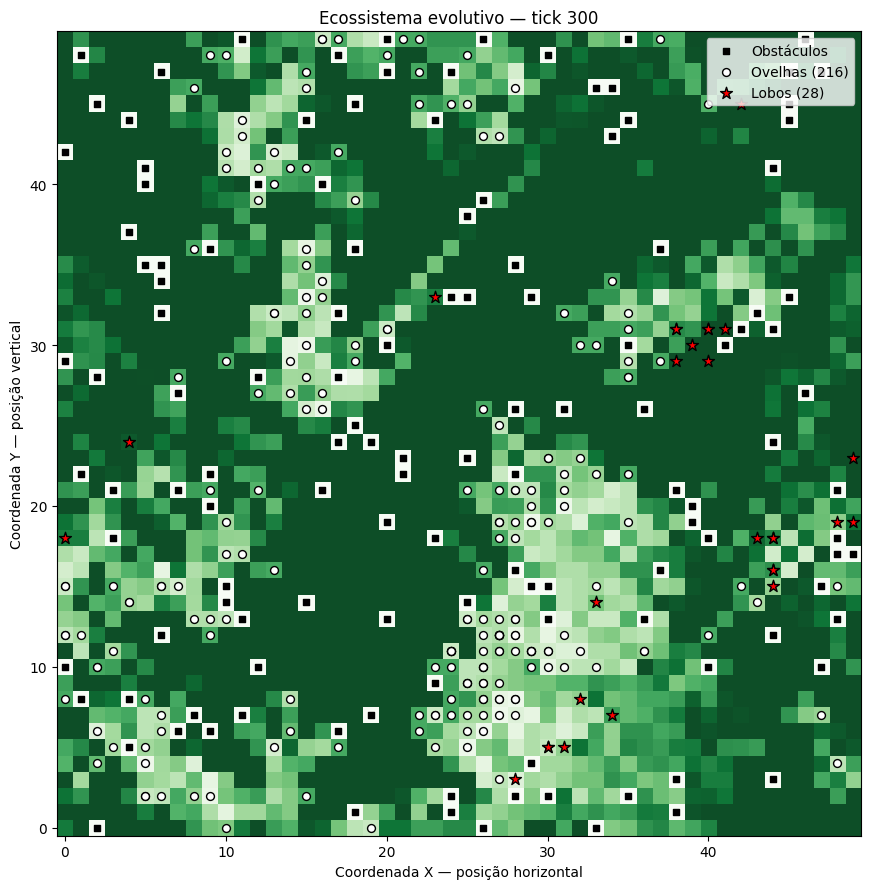

In [36]:
def plot_world(model):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(model.grass.T, origin="lower", cmap="Greens", vmin=0, vmax=model.p["grass_max"], alpha=0.95)
    ox, oy = np.where(model.obstacles)
    ax.scatter(ox, oy, s=16, c="black", marker="s", label="Obstáculos", zorder=2)
    sheep = get_sheep(model)
    wolves = get_wolves(model)
    if sheep:
        ax.scatter([s.pos[0] for s in sheep], [s.pos[1] for s in sheep], s=32, c="white", edgecolors="black", label=f"Ovelhas ({len(sheep)})", zorder=3)
    if wolves:
        ax.scatter([w.pos[0] for w in wolves], [w.pos[1] for w in wolves], s=80, c="red", edgecolors="black", marker="*", label=f"Lobos ({len(wolves)})", zorder=4)
    ax.set_title(f"Ecossistema evolutivo — tick {model.tick}")
    ax.set_xlabel("Coordenada X — posição horizontal")
    ax.set_ylabel("Coordenada Y — posição vertical")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_world(model)

## 8. Populações e recursos

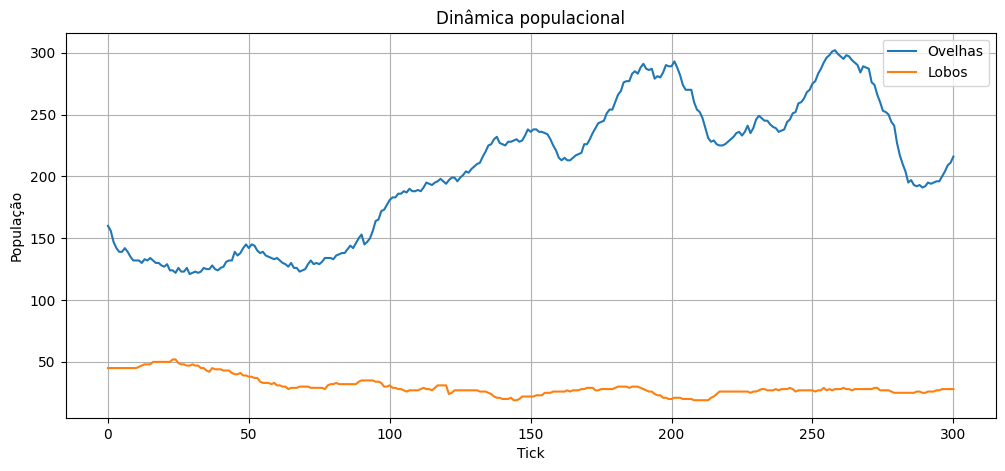

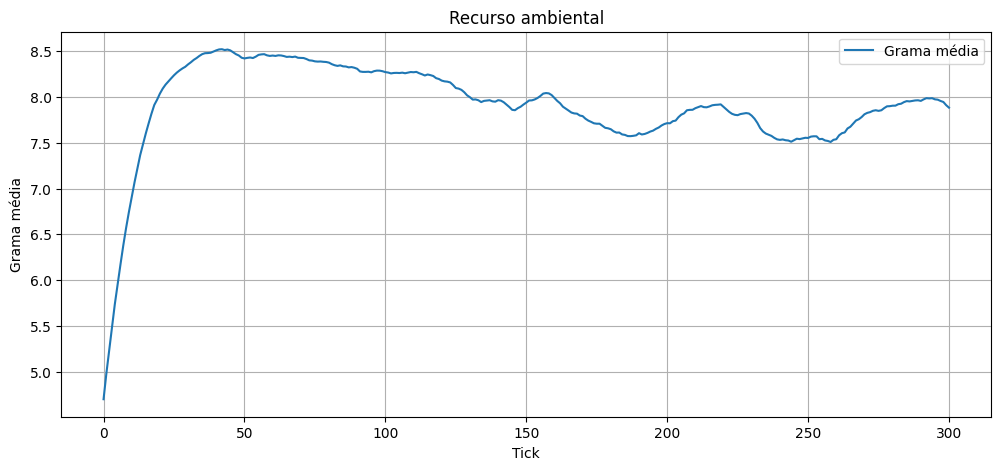

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df["tick"], df["sheep"], label="Ovelhas")
plt.plot(df["tick"], df["wolves"], label="Lobos")
plt.title("Dinâmica populacional")
plt.xlabel("Tick")
plt.ylabel("População")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["tick"], df["mean_grass"], label="Grama média")
plt.title("Recurso ambiental")
plt.xlabel("Tick")
plt.ylabel("Grama média")
plt.legend()
plt.grid(True)
plt.show()

## 9. Frequências alélicas nas ovelhas

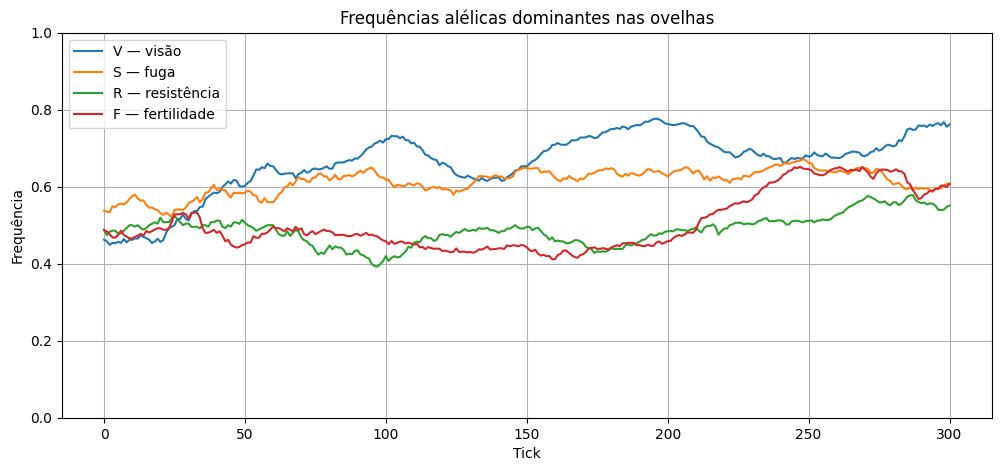

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(df["tick"], df["sheep_freq_V"], label="V — visão")
plt.plot(df["tick"], df["sheep_freq_S"], label="S — fuga")
plt.plot(df["tick"], df["sheep_freq_R"], label="R — resistência")
plt.plot(df["tick"], df["sheep_freq_F"], label="F — fertilidade")
plt.title("Frequências alélicas dominantes nas ovelhas")
plt.xlabel("Tick")
plt.ylabel("Frequência")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## 10. Frequências alélicas nos lobos

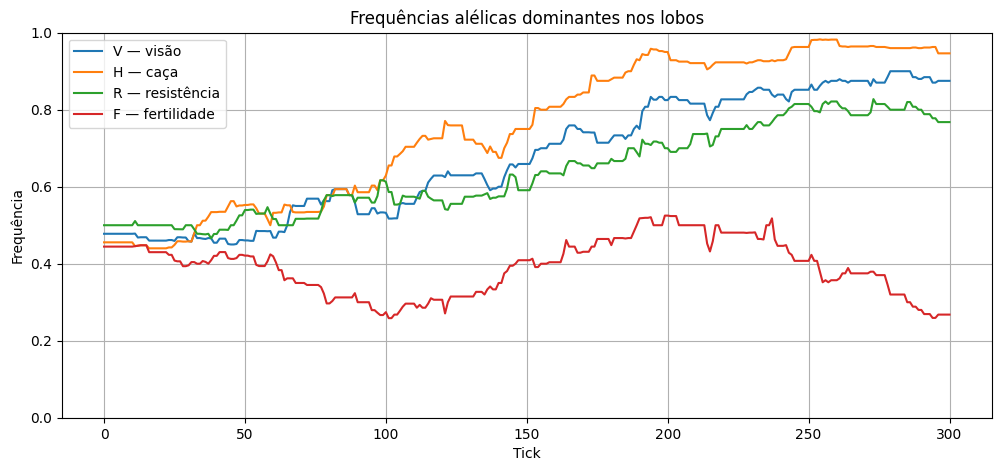

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(df["tick"], df["wolf_freq_V"], label="V — visão")
plt.plot(df["tick"], df["wolf_freq_H"], label="H — caça")
plt.plot(df["tick"], df["wolf_freq_R"], label="R — resistência")
plt.plot(df["tick"], df["wolf_freq_F"], label="F — fertilidade")
plt.title("Frequências alélicas dominantes nos lobos")
plt.xlabel("Tick")
plt.ylabel("Frequência")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## 11. Fenótipos médios

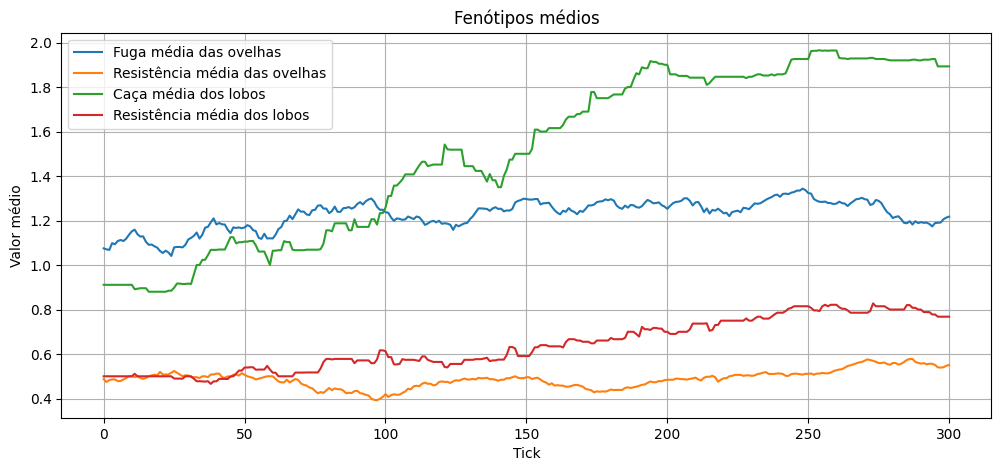

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(df["tick"], df["mean_sheep_escape"], label="Fuga média das ovelhas")
plt.plot(df["tick"], df["mean_sheep_resistance"], label="Resistência média das ovelhas")
plt.plot(df["tick"], df["mean_wolf_hunting"], label="Caça média dos lobos")
plt.plot(df["tick"], df["mean_wolf_resistance"], label="Resistência média dos lobos")
plt.title("Fenótipos médios")
plt.xlabel("Tick")
plt.ylabel("Valor médio")
plt.legend()
plt.grid(True)
plt.show()

## 12. Comparação com Lotka-Volterra

Lotka-Volterra não possui genética, espaço, idade, fome nem mutação. Ele é usado apenas como referência agregada predador-presa.

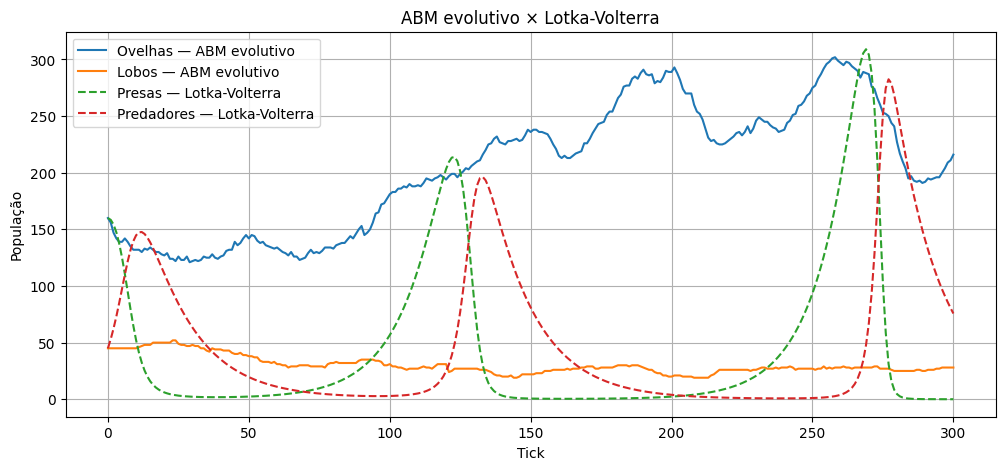

In [39]:
def lotka_volterra(prey0, predator0, steps, alpha=0.08, beta=0.002, delta=0.0015, gamma=0.06):
    prey = [prey0]
    predator = [predator0]
    for _ in range(steps):
        x = prey[-1]
        y = predator[-1]
        prey.append(max(0, x + alpha * x - beta * x * y))
        predator.append(max(0, y + delta * x * y - gamma * y))
    return pd.DataFrame({"tick": range(steps + 1), "lv_prey": prey, "lv_predator": predator})

df_lv = lotka_volterra(df["sheep"].iloc[0], df["wolves"].iloc[0], int(df["tick"].max()))
df_compare = df.merge(df_lv, on="tick", how="left")

plt.figure(figsize=(12, 5))
plt.plot(df_compare["tick"], df_compare["sheep"], label="Ovelhas — ABM evolutivo")
plt.plot(df_compare["tick"], df_compare["wolves"], label="Lobos — ABM evolutivo")
plt.plot(df_compare["tick"], df_compare["lv_prey"], "--", label="Presas — Lotka-Volterra")
plt.plot(df_compare["tick"], df_compare["lv_predator"], "--", label="Predadores — Lotka-Volterra")
plt.title("ABM evolutivo × Lotka-Volterra")
plt.xlabel("Tick")
plt.ylabel("População")
plt.legend()
plt.grid(True)
plt.show()

## 13. Amostra de genótipos sobreviventes

In [33]:
records = []
for a in get_sheep(model)[:10]:
    records.append({"tipo": "ovelha", "energia": a.energy, "idade": a.age, "genotipo": genotype_str(a.genome)})
for a in get_wolves(model)[:10]:
    records.append({"tipo": "lobo", "energia": a.energy, "idade": a.age, "genotipo": genotype_str(a.genome)})
pd.DataFrame(records)

,tipo,energia,idade,genotipo
0,ovelha,39.047344,89,F:FF R:Rr S:SS V:VV
1,ovelha,122.778463,88,F:ff R:rR S:ss V:vV
2,ovelha,9.429455,87,F:FF R:RR S:SS V:VV
3,ovelha,165.325573,85,F:fF R:Rr S:sS V:vV
4,ovelha,22.648285,83,F:FF R:Rr S:SS V:VV
5,ovelha,21.802102,82,F:FF R:rr S:Ss V:VV
6,ovelha,56.020178,82,F:FF R:rr S:sS V:vV
7,ovelha,29.252155,80,F:ff R:RR S:SS V:VV
8,ovelha,43.186685,79,F:fF R:RR S:SS V:VV
9,ovelha,25.584794,78,F:ff R:RR S:SS V:Vv


## 13.1 Amostra de genótipos sobreviventes com Interpretação

In [42]:
def explicar_genotipo(genome):
    nomes = {
        "F": "fertilidade",
        "R": "resistência à doença",
        "S": "fuga/velocidade",
        "V": "visão",
        "H": "caça"
    }

    partes = []

    for gene, alelos in sorted(genome.items()):
        a1, a2 = alelos
        dominante = sum(1 for a in alelos if a.isupper())

        if dominante == 2:
            expressao = "alta"
        elif dominante == 1:
            expressao = "intermediária"
        else:
            expressao = "baixa"

        partes.append(
            f"{gene}:{a1}{a2} → {nomes.get(gene, gene)} {expressao}"
        )

    return " | ".join(partes)
records = []

for a in get_sheep(model)[:10]:
    records.append({
        "tipo": "ovelha",
        "energia": round(a.energy, 2),
        "idade": a.age,
        "genotipo": genotype_str(a.genome),
        "interpretação": explicar_genotipo(a.genome)
    })

for a in get_wolves(model)[:10]:
    records.append({
        "tipo": "lobo",
        "energia": round(a.energy, 2),
        "idade": a.age,
        "genotipo": genotype_str(a.genome),
        "interpretação": explicar_genotipo(a.genome)
    })

df_genotipos = pd.DataFrame(records)
df_genotipos

,tipo,energia,idade,genotipo,interpretação
0,ovelha,39.05,89,F:FF R:Rr S:SS V:VV,F:FF → fertilidade alta | R:Rr → resistência à doença intermediária | S:SS → fuga/velocidade alta | V:VV → visão alta
1,ovelha,122.78,88,F:ff R:rR S:ss V:vV,F:ff → fertilidade baixa | R:rR → resistência à doença intermediária | S:ss → fuga/velocidade baixa | V:vV → visão intermediária
2,ovelha,9.43,87,F:FF R:RR S:SS V:VV,F:FF → fertilidade alta | R:RR → resistência à doença alta | S:SS → fuga/velocidade alta | V:VV → visão alta
3,ovelha,165.33,85,F:fF R:Rr S:sS V:vV,F:fF → fertilidade intermediária | R:Rr → resistência à doença intermediária | S:sS → fuga/velocidade intermediária | V:vV → visão intermediária
4,ovelha,22.65,83,F:FF R:Rr S:SS V:VV,F:FF → fertilidade alta | R:Rr → resistência à doença intermediária | S:SS → fuga/velocidade alta | V:VV → visão alta
5,ovelha,21.80,82,F:FF R:rr S:Ss V:VV,F:FF → fertilidade alta | R:rr → resistência à doença baixa | S:Ss → fuga/velocidade intermediária | V:VV → visão alta
6,ovelha,56.02,82,F:FF R:rr S:sS V:vV,F:FF → fertilidade alta | R:rr → resistência à doença baixa | S:sS → fuga/velocidade intermediária | V:vV → visão intermediária
7,ovelha,29.25,80,F:ff R:RR S:SS V:VV,F:ff → fertilidade baixa | R:RR → resistência à doença alta | S:SS → fuga/velocidade alta | V:VV → visão alta
8,ovelha,43.19,79,F:fF R:RR S:SS V:VV,F:fF → fertilidade intermediária | R:RR → resistência à doença alta | S:SS → fuga/velocidade alta | V:VV → visão alta
9,ovelha,25.58,78,F:ff R:RR S:SS V:Vv,F:ff → fertilidade baixa | R:RR → resistência à doença alta | S:SS → fuga/velocidade alta | V:Vv → visão intermediária


## 14. Exportação para CSV

In [ ]:
out_dir = Path("wolf_sheep_evolutivo_outputs")
out_dir.mkdir(exist_ok=True)

history_csv = out_dir / "wolf_sheep_evolutivo_historico.csv"
compare_csv = out_dir / "wolf_sheep_evolutivo_lotka_volterra.csv"

df.to_csv(history_csv, index=False, encoding="utf-8-sig")
df_compare.to_csv(compare_csv, index=False, encoding="utf-8-sig")

history_csv, compare_csv

## 15. Interpretação

Este modelo agora integra ecologia e evolução.

A ecologia aparece na relação:

```text
grama → ovelhas → lobos
```

A evolução aparece porque os indivíduos possuem genótipos diferentes, transmitem alelos aos descendentes, sofrem mutações e são selecionados pelo ambiente.

Se um alelo aumenta de frequência, pode indicar vantagem adaptativa naquele contexto. Por exemplo:

- `S` pode aumentar se a fuga das ovelhas for importante.
- `H` pode aumentar se a caça eficiente favorecer lobos.
- `R` pode aumentar se a doença for uma pressão seletiva forte.
- `F` pode aumentar se maior fertilidade compensar custos de sobrevivência.